# **Import Everything**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import math
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import(accuracy_score,
                            classification_report,
                            confusion_matrix)
from sklearn.model_selection import train_test_split
print('Everything is loaded boss')

Everything is loaded boss


# **Data Exploration**

## **Load the Data**

In [2]:
file_path = input("Enter the File Path Baby: ")
df = pd.read_csv(file_path)
print('Data Loaded Baby')

Data Loaded Baby


## **Exploration**

In [3]:
print(f'The dataset have {df.shape[0]} Rows and {df.shape[1]} columns with {df.duplicated().sum()} Duplicates')

The dataset have 30300 Rows and 10 columns with 298 Duplicates


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30300 entries, 0 to 30299
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                29695 non-null  float64
 1   years_at_company   29695 non-null  float64
 2   performance_score  29693 non-null  str    
 3   training_hours     29694 non-null  float64
 4   awards_won         29696 non-null  float64
 5   avg_review_score   29696 non-null  float64
 6   num_reports        29692 non-null  float64
 7   dept_kpi_score     29694 non-null  float64
 8   prev_promoted      29696 non-null  float64
 9   promoted           30300 non-null  int64  
dtypes: float64(8), int64(1), str(1)
memory usage: 2.4 MB


In [5]:
df.sample(10)

,age,years_at_company,performance_score,training_hours,awards_won,avg_review_score,num_reports,dept_kpi_score,prev_promoted,promoted
1649,49.0,15.0,72.2,14.0,0.0,46.4,5.0,5.6,0.0,0
7916,34.0,10.0,87.8,33.0,3.0,89.7,6.0,6.8,1.0,1
1615,46.0,6.0,NaN,10.0,0.0,73.9,2.0,1.3,0.0,0
2472,50.0,20.0,95.1,87.0,2.0,81.5,0.0,8.8,0.0,1
27404,40.0,23.0,91.3,41.0,1.0,83.1,9.0,4.1,0.0,1
8020,41.0,21.0,51.4,38.0,0.0,76.8,3.0,8.0,0.0,0
29968,50.0,17.0,84.1,41.0,2.0,71.3,6.0,5.5,1.0,1
21396,48.0,13.0,59.9,24.0,1.0,83.1,5.0,3.6,0.0,0
7085,36.0,16.0,78.2,32.0,4.0,74.8,NaN,5.6,0.0,0
1101,34.0,9.0,94.1,88.0,2.0,84.5,2.0,9.4,0.0,1


In [6]:
df.describe()

,age,years_at_company,training_hours,awards_won,avg_review_score,num_reports,dept_kpi_score,prev_promoted,promoted
count,29695.000000,29695.000000,29694.000000,29696.000000,29696.000000,29692.000000,29694.000000,29696.000000,30300.000000
mean,40.517528,12.436067,49.291641,2.007577,70.121734,4.476728,5.514262,0.302431,0.500990
std,10.952235,6.918670,28.817054,1.418580,17.298871,2.867388,2.599374,0.459319,0.500007
min,-5.000000,-3.000000,-10.000000,-2.000000,40.000000,0.000000,1.000000,0.000000,0.000000
25%,31.000000,6.000000,24.000000,1.000000,55.200000,2.000000,3.300000,0.000000,0.000000
50%,41.000000,12.000000,49.000000,2.000000,70.200000,4.000000,5.500000,0.000000,1.000000
75%,50.000000,18.000000,74.000000,3.000000,85.100000,7.000000,7.800000,1.000000,1.000000
max,59.000000,24.000000,99.000000,4.000000,100.000000,9.000000,20.000000,1.000000,1.000000


In [7]:
df.isna().sum()

age                  605
years_at_company     605
performance_score    607
training_hours       606
awards_won           604
avg_review_score     604
num_reports          608
dept_kpi_score       606
prev_promoted        604
promoted               0
dtype: int64

# **Data Cleaning**

## **Create Copy**

In [8]:
df_copy = df.copy()
print('Copy Created')

Copy Created


## **DataType**

In [10]:
df_copy['performance_score'] = df_copy['performance_score'].replace('_err','',regex=True).astype('float')

## **Impossible values**

In [12]:
Columns = df_copy.columns.tolist()
Columns.remove('age')

for col in Columns:
    df_copy.loc[df_copy[col]<0,col] = np.nan

df_copy.loc[df_copy['age']>100,'age'] = np.nan
df_copy.loc[df_copy['age']<18,'age'] = np.nan

## **Outliers**

In [14]:
Columns = ['performance_score','training_hours','avg_review_score','dept_kpi_score','years_at_company']

for col in Columns:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_copy.loc[df_copy[col] < lower, col] = np.nan
    df_copy.loc[df_copy[col] > upper, col] = np.nan

print("Outliers Handled ✅")

Outliers Handled ✅


## **Duplicates**

In [16]:
print("Dateset have duplicates: ")
print(f"Before: {df_copy.duplicated().sum()}")
df_copy.drop_duplicates(inplace=True)
print(f"After: {df_copy.duplicated().sum()}")

Dateset have duplicates: 
Before: 300
After: 0


## **NaN Values**

In [17]:
print("NaN values in the Dataset is: ")
print(df_copy.isna().sum())

Round = ['performance_score','training_hours','avg_review_score','dept_kpi_score']

for col in Round:
    df_copy[col] = df_copy[col].fillna(round(df_copy[col].median(),2))
    
Floor = ['age','years_at_company','awards_won','num_reports','prev_promoted']
for col in Floor:
    df_copy[col] = df_copy[col].fillna(math.floor(df_copy[col].median()))
    
print("NaN values in the Dataset After Cleaning is: ")
print(df_copy.isna().sum())

NaN values in the Dataset is: 
age                  601
years_at_company     601
performance_score    601
training_hours       601
awards_won           601
avg_review_score     600
num_reports          600
dept_kpi_score       601
prev_promoted        600
promoted               0
dtype: int64
NaN values in the Dataset After Cleaning is: 
age                  0
years_at_company     0
performance_score    0
training_hours       0
awards_won           0
avg_review_score     0
num_reports          0
dept_kpi_score       0
prev_promoted        0
promoted             0
dtype: int64


# **Data Preperation**

In [18]:
features = df_copy.columns.tolist()
features.remove('promoted')
X = df_copy[features]
y = df_copy['promoted']
print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

X Shape: (30000, 9)
y Shape: (30000,)


In [19]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,train_size=0.8)

print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape:  {X_test.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"y_test Shape:  {y_test.shape}")

X_train Shape: (24000, 9)
X_test Shape:  (6000, 9)
y_train Shape: (24000,)
y_test Shape:  (6000,)


In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# **Model**

## **Train**

In [21]:
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=20,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)

print(f"Best trees used: {model.best_iteration}")
print(f"Model trained ✅")

Best trees used: 79
Model trained ✅


## **Evaluation & Pridict**

In [22]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

         0.0       0.75      0.76      0.76      3003
         1.0       0.76      0.75      0.75      2997

    accuracy                           0.76      6000
   macro avg       0.76      0.76      0.76      6000
weighted avg       0.76      0.76      0.76      6000

Accuracy: 0.7557


## **Feature importance**

In [23]:
importance_types = ['weight', 'gain', 'cover']

for imp_type in importance_types:
    imp = model.get_booster().get_score(importance_type=imp_type)
    print(f"\n{imp_type.upper()}:")
    for feat, score in sorted(imp.items(), key=lambda x: x[1], reverse=True):
        print(f"  {feat:25} → {score:.4f}")


WEIGHT:
  f2                        → 513.0000
  f5                        → 487.0000
  f3                        → 447.0000
  f7                        → 405.0000
  f1                        → 316.0000
  f0                        → 306.0000
  f6                        → 206.0000
  f4                        → 203.0000
  f8                        → 145.0000

GAIN:
  f4                        → 74.3565
  f8                        → 25.7373
  f1                        → 19.8450
  f2                        → 19.5253
  f5                        → 15.7668
  f3                        → 12.9308
  f6                        → 9.1647
  f0                        → 6.5441
  f7                        → 6.4837

COVER:
  f4                        → 1362.4960
  f8                        → 878.0858
  f1                        → 673.8043
  f2                        → 614.7787
  f6                        → 554.2962
  f5                        → 506.3822
  f3                        → 503.4666
  f0        

## **Gap**

In [24]:
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
test_acc  = accuracy_score(y_test,  y_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Gap:               {(train_acc - test_acc):.4f}")
print(f"Best iteration:    {model.best_iteration}")

Training Accuracy: 0.7875
Testing Accuracy:  0.7557
Gap:               0.0318
Best iteration:    79


## **Charts**

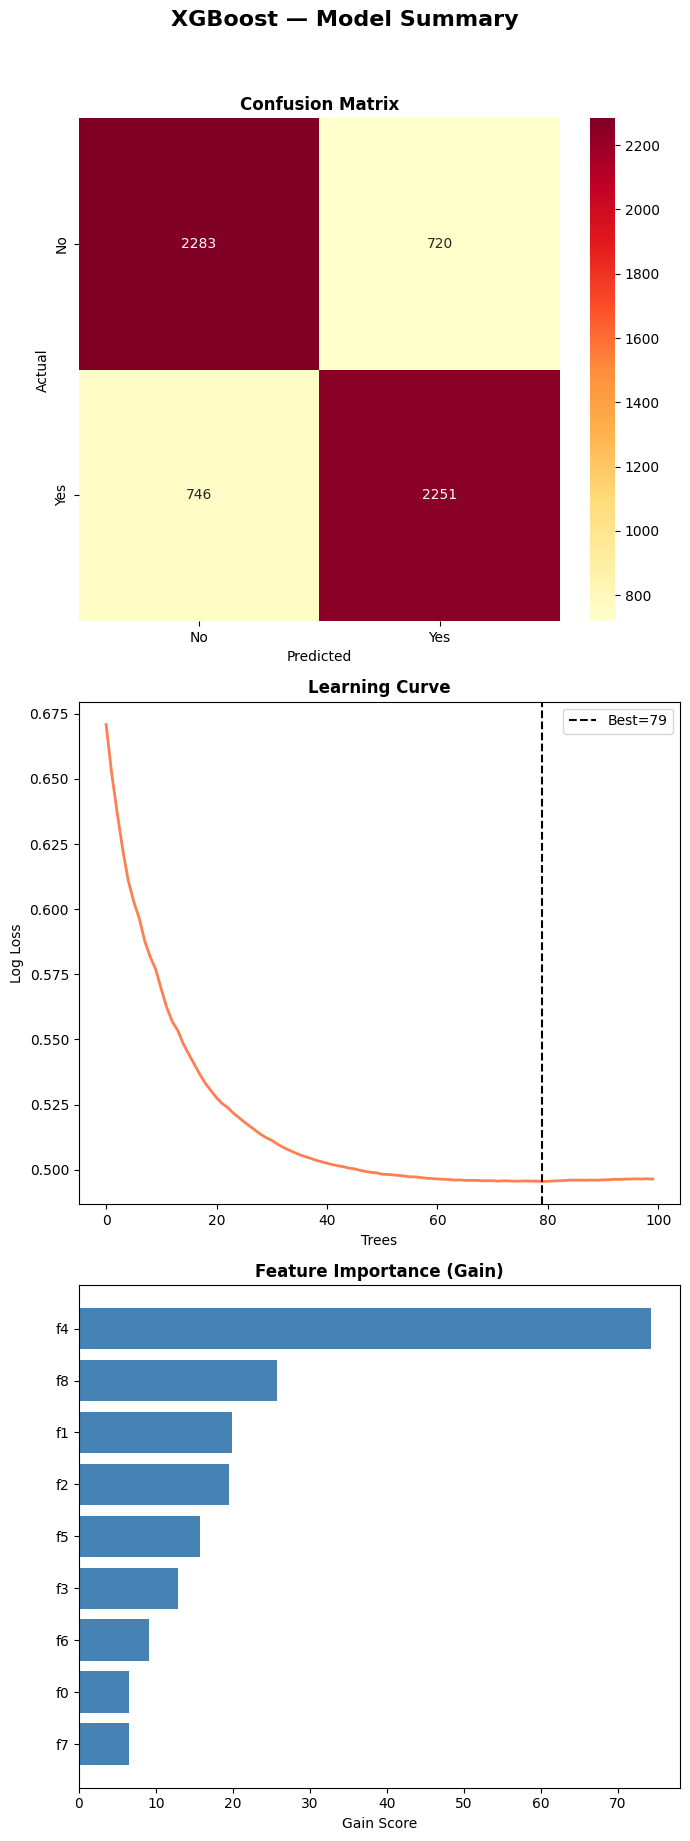

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(7, 18))

# Plot 1 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot 2 — Learning Curve
results = model.evals_result()
axes[1].plot(results['validation_0']['logloss'],
             color='coral', linewidth=2)
axes[1].axvline(model.best_iteration, linestyle='--',
                color='black', label=f'Best={model.best_iteration}')
axes[1].set_title('Learning Curve', fontweight='bold')
axes[1].set_xlabel('Trees')
axes[1].set_ylabel('Log Loss')
axes[1].legend()

# Plot 3 — Feature Importance (Gain)
imp_df = pd.DataFrame(
    model.get_booster().get_score(importance_type='gain').items(),
    columns=['Feature', 'Gain']
).sort_values('Gain')
axes[2].barh(imp_df['Feature'], imp_df['Gain'], color='steelblue')
axes[2].set_title('Feature Importance (Gain)', fontweight='bold')
axes[2].set_xlabel('Gain Score')

plt.suptitle('XGBoost — Model Summary',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()